# Setup and data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src...` works

import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm

from scipy import signal, stats
from scipy.optimize import curve_fit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display, Image

from src import config as cfg
from src import ecog_cnn as ec
from src.io_utils import save_fig, save_cache, load_cache, get_device

rcParams['figure.figsize'] = [14, 4]
rcParams['font.size'] = 12
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

np.random.seed(cfg.RNG_SEED)


In [2]:
usable = cfg.usable
NOISE_LEVELS = cfg.NOISE_LEVELS
CONDITIONS = cfg.CONDITIONS
N_COND = cfg.N_COND
GROUP_NAMES = cfg.GROUP_NAMES
layer_names = cfg.layer_names
n_stim = cfg.n_stim
fs = cfg.fs
trange_d1 = cfg.trange_d1
baseline_d1 = cfg.baseline_d1
response_d1 = cfg.response_d1
trange_d2 = cfg.trange_d2
response_win = cfg.response_win
AUC_CRIT = cfg.AUC_CRIT
FACE_SEL_THRESH = cfg.FACE_SEL_THRESH
FACE_SEL_CRIT = cfg.FACE_SEL_CRIT
WIN_WIDTH, WIN_STEP, WIN_STARTS = cfg.WIN_WIDTH, cfg.WIN_STEP, cfg.WIN_STARTS
MIN_TRIALS_PER_CONDITION = cfg.MIN_TRIALS_PER_CONDITION
MIN_GROUP_SIZE = cfg.MIN_GROUP_SIZE
NOISE_HALFWIN = cfg.NOISE_HALFWIN
POP_HALFWIN = cfg.POP_HALFWIN
MIN_TRIALS_POP = cfg.MIN_TRIALS_POP

common_average_reference = ec.common_average_reference
broadband_power = ec.broadband_power
classify_region = ec.classify_region
compute_avg_magnitude = ec.compute_avg_magnitude
phase_scramble = ec.phase_scramble
crossnobis_1d = ec.crossnobis_1d
crossnobis_multivariate = ec.crossnobis_multivariate
cv_auc = ec.cv_auc
mean_ci95 = ec.mean_ci95
upper_tri = ec.upper_tri
compare_rdms = ec.compare_rdms
filter_outlier_trials = ec.filter_outlier_trials
partial_spearman = ec.partial_spearman
threshold_cross = ec.threshold_cross
corr_sigmoid = ec.corr_sigmoid
auc_sigmoid = ec.auc_sigmoid
fit_threshold = ec.fit_threshold
build_layer_rdm_crossnobis = ec.build_layer_rdm_crossnobis
build_layer_rdms_bootstrap_once = ec.build_layer_rdms_bootstrap_once
similarity_to_baseline = ec.similarity_to_baseline
build_comparison_df = ec.build_comparison_df
auc_face_vs_house = ec.auc_face_vs_house
perm = ec.category_major_perm()
reorder_rdm = ec.reorder_rdm
get_noise_window_indices = ec.get_noise_window_indices
subset_rdm = ec.subset_rdm

REG_COLORS = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange'}
group_colors = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange',
                'face_selective': 'tab:red', 'all': 'tab:gray'}
COND_NOISE = np.array([int(c.split('_')[1]) for c in CONDITIONS])
COND_ISFACE = np.array([c.startswith('face') for c in CONDITIONS]).astype(int)
layer_x = np.arange(len(layer_names))


## Dataset info

Two ECoG sessions per subject from Miller et al. (2014-2017), recorded during
a face/house perception task. Raw data: https://exhibits.stanford.edu/data/catalog/zk881ps0522

**Experiment 1 (`dat1`, passive viewing):**
`V` (voltage, time x channels), `srate` (1000 Hz), `t_on`/`t_off` (stim onset/offset,
always 400 samples apart), `stim_id` (1-100; 1-50 = houses, 51-100 = faces), `locs`
(3D electrode positions).

**Experiment 2 (`dat2`, noisy face detection):**
`V`, `srate`, `t_on`/`t_off` (1000 samples apart, **no gap between trials**),
`stim_id` (not useful — no repeats), `stim_cat` (1 = house, 2 = face),
`stim_noise` (0-100% phase noise), `key_press` (face-detection response),
`locs`.

Sample rate 1000 Hz; data notch-filtered at 60/120/180/240/250 Hz and
z-scored across time.


In [3]:
alldat = ec.load_alldat()
print(f"Loaded alldat: {alldat.shape[0]} subjects, each with [dat1 (passive), dat2 (noisy detection)]")
print("dat1 keys:", list(alldat[1][0].keys()))
print("dat2 keys:", list(alldat[1][1].keys()))


Loaded alldat: 7 subjects, each with [dat1 (passive), dat2 (noisy detection)]
dat1 keys: ['t_off', 'stim_id', 't_on', 'srate', 'V', 'scale_uv', 'locs', 'hemisphere', 'lobe', 'gyrus', 'Brodmann_Area']
dat2 keys: ['stim_id', 'stim_cat', 'stim_noise', 't_on', 't_off', 'key_press', 'V', 'categories', 'scale_uv', 'locs', 'hemisphere', 'lobe', 'gyrus', 'Brodmann_Area']


In [4]:
# @title Check inter-stimulus interval (ISI) — determines where a valid baseline exists

# SOA (stimulus onset asynchrony) = onset(n+1) - onset(n); ISI = SOA - stimulus duration.
# This single measurement decides every preprocessing choice below: a pre-stimulus
# baseline is only valid where the previous trial's response has decayed, i.e. where ISI > 0.

usable = [0, 3, 4, 5, 6]   # subjects used throughout (others excluded for data-quality reasons upstream)

print("Measured SOA / ISI from stimulus onset times:")
for s in usable:
    d1, d2 = alldat[s][0], alldat[s][1]
    soa1 = np.median(np.diff(np.asarray(d1['t_on']).ravel()))
    soa2 = np.median(np.diff(np.asarray(d2['t_on']).ravel()))
    print(f"  S{s}: dat1 SOA={soa1:.0f}ms (stim 400ms)  -> ISI={soa1-400:.0f}ms | "
          f"dat2 SOA={soa2:.0f}ms (stim 1000ms) -> ISI={soa2-1000:.0f}ms")

print("""
CONSEQUENCE (drives all preprocessing below):
  dat1: ISI ~ 400ms  -> the -200..0ms window is blank screen -> valid pre-stim baseline.
  dat2: ISI = 0ms     -> the -200..0ms window IS the previous image's response.
                         A "baseline" there would be signal minus signal, not signal minus rest.
  Rule applied everywhere below: any measure that requires a baseline (visual
  responsiveness) is computed in dat1. Everything computed in dat2 is either
  baseline-free (z-scored across trials) or a relative/discriminative measure
  (AUC, crossnobis distance between two stimulus-driven conditions) that never
  needs an absolute reference point.
""")


Measured SOA / ISI from stimulus onset times:
  S0: dat1 SOA=800ms (stim 400ms)  -> ISI=400ms | dat2 SOA=1000ms (stim 1000ms) -> ISI=0ms
  S3: dat1 SOA=800ms (stim 400ms)  -> ISI=400ms | dat2 SOA=1000ms (stim 1000ms) -> ISI=0ms
  S4: dat1 SOA=800ms (stim 400ms)  -> ISI=400ms | dat2 SOA=1000ms (stim 1000ms) -> ISI=0ms
  S5: dat1 SOA=800ms (stim 400ms)  -> ISI=400ms | dat2 SOA=1000ms (stim 1000ms) -> ISI=0ms
  S6: dat1 SOA=800ms (stim 400ms)  -> ISI=400ms | dat2 SOA=1000ms (stim 1000ms) -> ISI=0ms

CONSEQUENCE (drives all preprocessing below):
  dat1: ISI ~ 400ms  -> the -200..0ms window is blank screen -> valid pre-stim baseline.
  dat2: ISI = 0ms     -> the -200..0ms window IS the previous image's response.
                         A "baseline" there would be signal minus signal, not signal minus rest.
  Rule applied everywhere below: any measure that requires a baseline (visual
  responsiveness) is computed in dat1. Everything computed in dat2 is either
  baseline-free (z-scored acros

In [5]:
# @title Electrode locations on the brain surface (subject 1, dat1)

from nilearn import plotting
from nimare import utils

dat1_s1 = alldat[1][0]
locs = dat1_s1['locs']
view = plotting.view_markers(
    utils.tal2mni(locs),
    marker_labels=[f'{k}' for k in np.arange(locs.shape[0])],
    marker_color='purple', marker_size=5
)
view


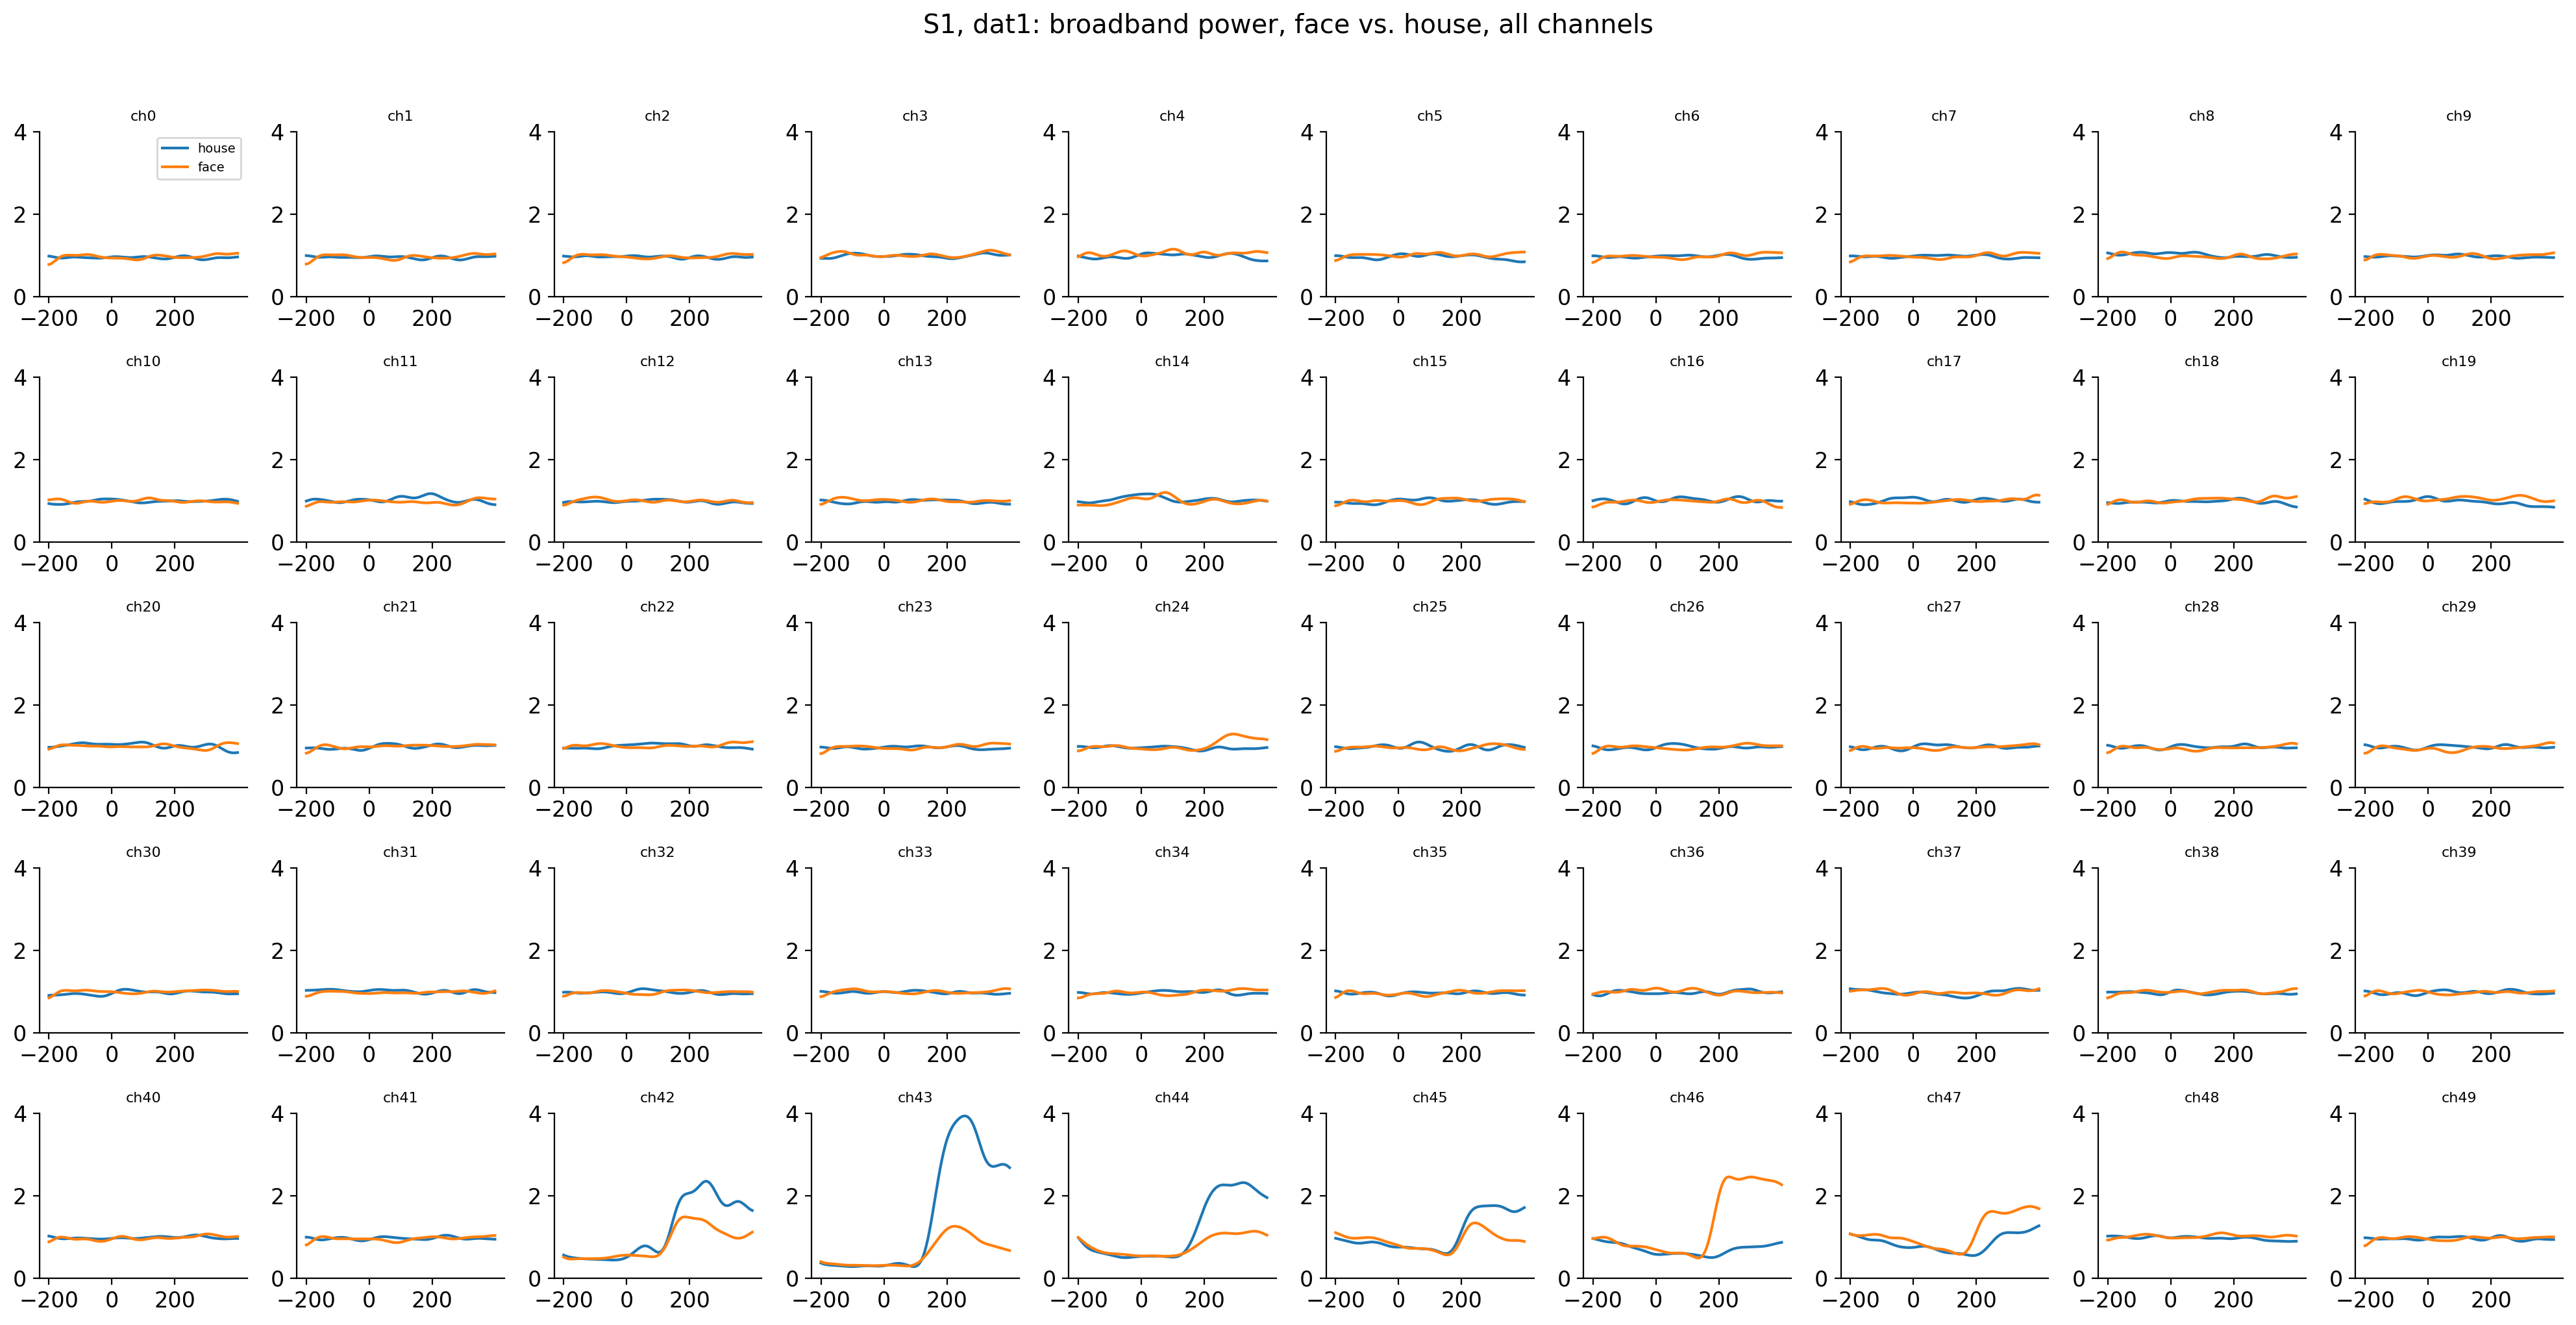

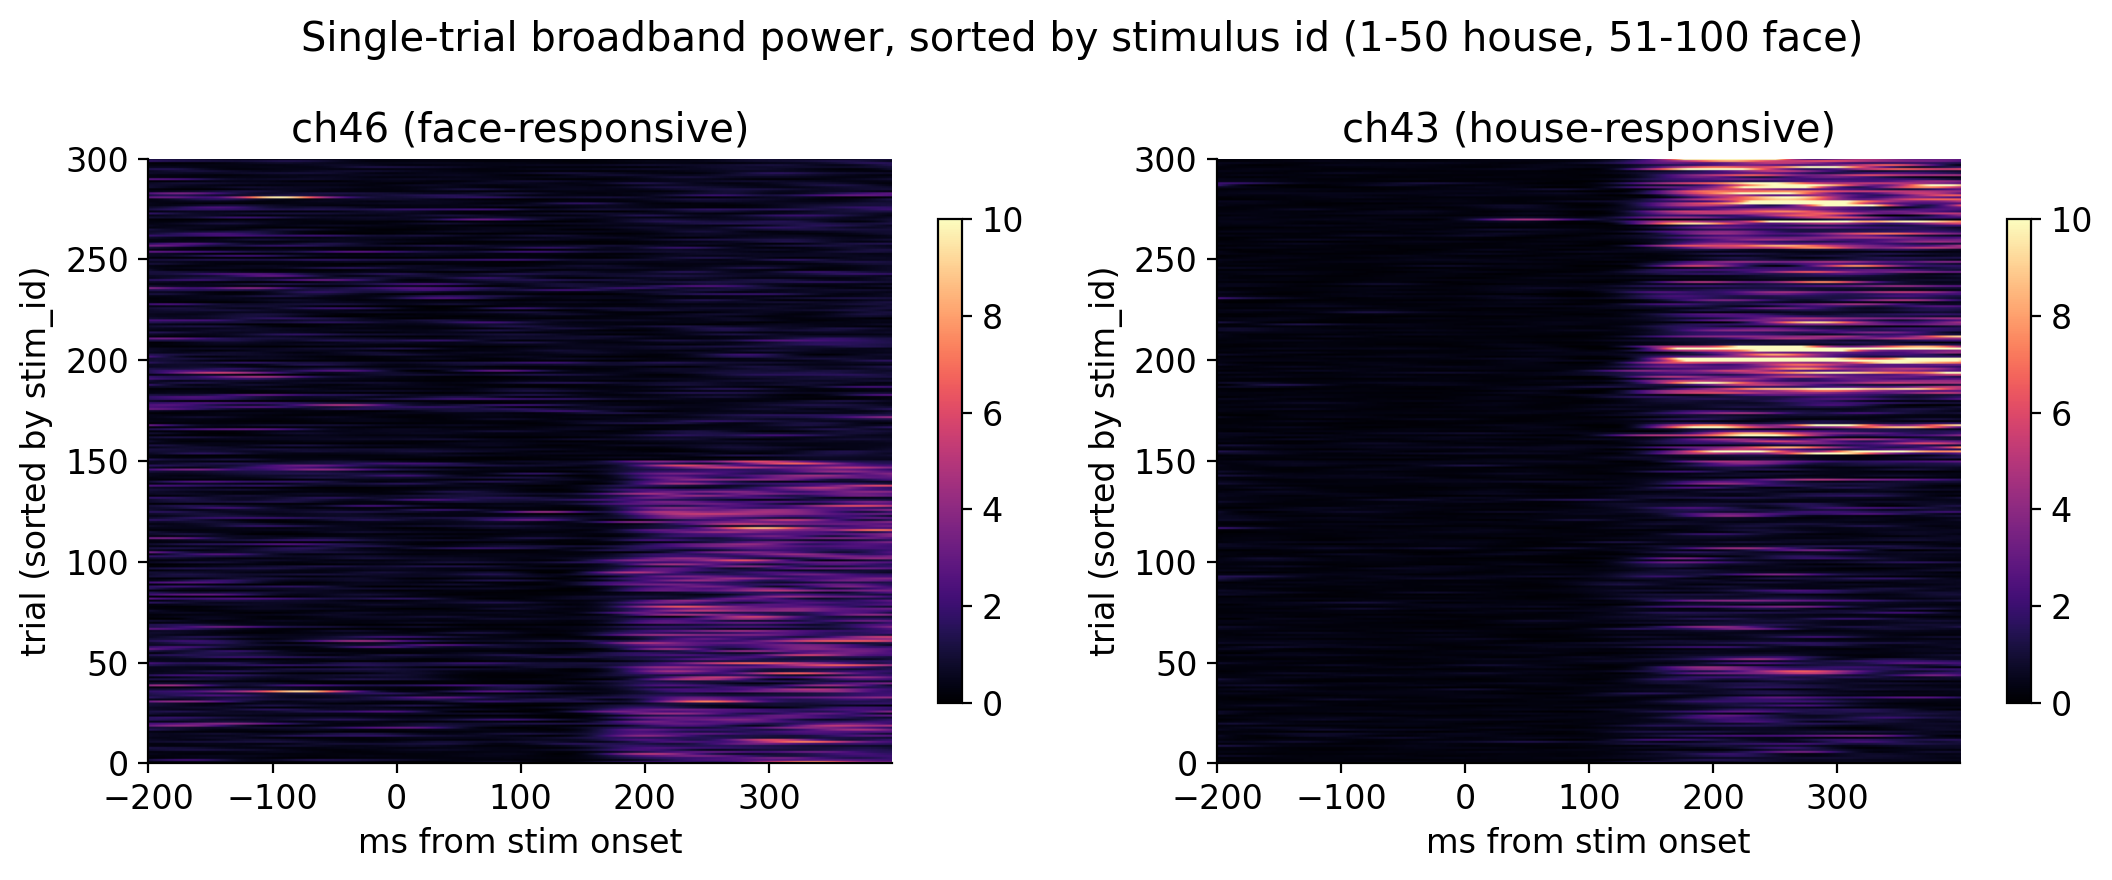

In [6]:
# @title Quick sanity check: broadband power, faces vs. houses (subject 1, dat1)

# broadband power pipeline: high-pass -> square -> low-pass envelope

def quick_broadband(V, fs=1000):
    b, a = signal.butter(3, [50], btype='high', fs=fs)
    Vb = signal.filtfilt(b, a, V, axis=0)
    Vb = np.abs(Vb) ** 2
    b, a = signal.butter(3, [10], btype='low', fs=fs)
    Vb = signal.filtfilt(b, a, Vb, axis=0)
    return Vb / Vb.mean(axis=0)

dat1_s1 = alldat[1][0]
V = quick_broadband(dat1_s1['V'].astype('float32'))
nt, nchan = V.shape
nstim = len(dat1_s1['t_on'])
trange = np.arange(-200, 400)
ts = dat1_s1['t_on'][:, np.newaxis] + trange
V_epochs = np.reshape(V[ts, :], (nstim, 600, nchan))
V_house = (V_epochs[dat1_s1['stim_id'] <= 50]).mean(0)
V_face = (V_epochs[dat1_s1['stim_id'] > 50]).mean(0)

fig, axes = plt.subplots(5, 10, figsize=(20, 10))
for j, ax in enumerate(axes.flat):
    if j >= 50:
        ax.axis('off'); continue
    ax.plot(trange, V_house[:, j], label='house' if j == 0 else None)
    ax.plot(trange, V_face[:, j], label='face' if j == 0 else None)
    ax.set_title(f'ch{j}', fontsize=8); ax.set_xticks([-200, 0, 200]); ax.set_ylim([0, 4])
axes.flat[0].legend(fontsize=7)
plt.suptitle('S1, dat1: broadband power, face vs. house, all channels', y=1.02)
plt.tight_layout(); display(Image(save_fig(fig, '00_setup_and_data_fig01'))); plt.close(fig)

# Two example electrodes known to separate categories: ch46 (face-preferring), ch43 (house-preferring)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, ch, label in zip(axes, [46, 43], ['ch46 (face-responsive)', 'ch43 (house-responsive)']):
    isort = np.argsort(dat1_s1['stim_id'])
    im = ax.imshow(V_epochs[isort, :, ch].astype('float32'), aspect='auto', vmax=10, vmin=0,
                   cmap='magma', extent=[trange[0], trange[-1], 0, len(isort)])
    ax.set_title(label); ax.set_xlabel('ms from stim onset'); ax.set_ylabel('trial (sorted by stim_id)')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Single-trial broadband power, sorted by stimulus id (1-50 house, 51-100 face)')
plt.tight_layout(); display(Image(save_fig(fig, '00_setup_and_data_fig02'))); plt.close(fig)
